In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import optuna
from optuna.integration import OptunaSearchCV
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

=------------------------------------- Exploratory Data analysis -------------------------------------=

In this section I implement a complete exploratory analysis pipeline to inspect data quality, distributions and basic relationships:

- Data loading with custom column names and proper handling of missing value markers ('?')
- Custom data audit function df_info() that generates a detailed overview table including:
  - column data types
  - missing value counts
  - empty string detection
  - unique value counts
  - preview of unique values (limited display for readability)
- Missingness analysis per record with percentage breakdown 
- Clear separation of features into semantic groups: numerical, binary categorical, nominal categorical, ordinal categorical
- Creation of binary target variable from the original multi-class 'num'
- Descriptive statistics table for numerical features
- Class distribution tables
- Outlier detection using IQR rule with summary table showing count and percentage per numerical feature
- Distribution visualization pipeline for categorical features:
  - individual count plots with percentage annotations
  - grouped count plots vs binary target (side-by-side healthy vs diseased)
- Multi-view distribution analysis for numerical features:
  - per-feature grid: histogram + KDE + boxplot + violin plot
  - combined comparison: all numerical features in boxplot vs violin plot
  - grouped boxplots: each numerical feature split by binary target
- Correlation analysis:
  - Pearson correlation heatmap among numerical features
  - Sorted table of Pearson correlations with the binary target
- Statistical association testing:
  - Chi-square test of independence for every categorical feature vs binary target
  - Results collected into a sorted table (by chi-square statistic)

The code automatically handles NaN values in visualizations (treated as category "NaN"), ensures consistent category ordering, and uses consistent color palettes for better readability.

All tables are styled for clarity and displayed using pandas styling capabilities.

In [3]:
colnames = ["age","sex","cp","trestbps","chol","fbs","restecg", "thalach","exang","oldpeak","slope","ca","thal","num"]

df = pd.read_csv("processed.cleveland.data", names=colnames, na_values='?')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
def show_unique_values(series):
    vals = series.unique()
    if len(vals) <= 10:
        return list(vals)
    return "too many values"

def df_info(df):
    print("FULL DATA AUDIT TABLE")

    nan_counts = df.isna().sum()

    empty_counts = df.apply(
        lambda col: col.apply(lambda x: isinstance(x, str) and x.strip() == "").sum()
        if col.dtype == object else 0
    )

    unique_counts = df.nunique()

    unique_values_preview = df.apply(show_unique_values)

    audit_table = pd.DataFrame({
        "dtype": df.dtypes,
        "NaN_count": nan_counts,
        "Empty_string_count": empty_counts,
        "Unique_values": unique_counts,
        "Unique_values_preview": unique_values_preview
    })

    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.width", None)

    display(audit_table)

In [6]:
df_info(df)

rows, cols = df.shape
print(f"Dataset: {rows} rows, {cols} columns")

FULL DATA AUDIT TABLE


,dtype,NaN_count,Empty_string_count,Unique_values,Unique_values_preview
age,float64,0,0,41,too many values
sex,float64,0,0,2,"[1.0, 0.0]"
cp,float64,0,0,4,"[1.0, 4.0, 3.0, 2.0]"
trestbps,float64,0,0,50,too many values
chol,float64,0,0,152,too many values
fbs,float64,0,0,2,"[1.0, 0.0]"
restecg,float64,0,0,3,"[2.0, 0.0, 1.0]"
thalach,float64,0,0,91,too many values
exang,float64,0,0,2,"[0.0, 1.0]"
oldpeak,float64,0,0,40,too many values


Dataset: 303 rows, 14 columns


In [7]:
missing_per_row = df.isna().sum(axis=1)

counts = missing_per_row.value_counts().sort_index()
counts.name = "Number of records"

df_missing = pd.DataFrame({
    "Number of missing features": counts.index,
    "Number of records": counts.values,
    "Percentage of dataset": (counts / len(df) * 100).round(1)
})

df_missing["Percentage of dataset"] = df_missing["Percentage of dataset"].astype(str) + " %"

display(df_missing.style
    .hide(axis="index")
    .set_caption("Number of Missing Features per Record")
)

Number of missing features,Number of records,Percentage of dataset
0,297,98.0 %
1,6,2.0 %


In [5]:
numerical = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_categorical = ['sex', 'fbs', 'exang']
nominal_categorical = ['cp', 'restecg', 'thal']
ordinal_categorical = ['slope', 'ca']
target = 'num'

x = df.drop(columns=[target])
y = df[target].astype(int)
y_binary = (df[target] > 0).astype(int)

In [9]:
desc_stats = df[numerical].describe()

display(desc_stats.style
    .set_caption("Descriptive statistics for numerical features")
)

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


In [10]:
multi_dist = (df['num'].value_counts(normalize=True).sort_index().round(4).reset_index())
multi_dist.columns = ['Class', 'Proportion']

binary_dist = (y_binary.value_counts(normalize=True).sort_index().round(4).reset_index())
binary_dist.columns = ['Class', 'Proportion']

display(multi_dist.style
    .set_caption("Multi-class distribution:")
)

display(binary_dist.style
    .set_caption("Binary distribution:")
)

,Class,Proportion
0,0,0.541300
1,1,0.181500
2,2,0.118800
3,3,0.115500
4,4,0.042900


,Class,Proportion
0,0,0.541300
1,1,0.458700


In [11]:
def detect_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((col < lower) | (col > upper)).sum()

outlier_results = []
for col in numerical:
    count = detect_outliers(df[col])
    outlier_results.append({
        'Feature': col,
        'Outliers Count': count,
        'Outliers Percent': round(count / len(df) * 100, 2)
    })
    
df_outliers = pd.DataFrame(outlier_results)
df_outliers = df_outliers.sort_values('Outliers Count', ascending=False).reset_index(drop=True)

display(df_outliers.style
    .set_caption("Outliers Detection (IQR Method)")
    .format({'Outliers %': '{:.2f}%'})
)

,Feature,Outliers Count,Outliers Percent
0,trestbps,9,2.970000
1,oldpeak,5,1.650000
2,chol,5,1.650000
3,thalach,1,0.330000
4,age,0,0.000000


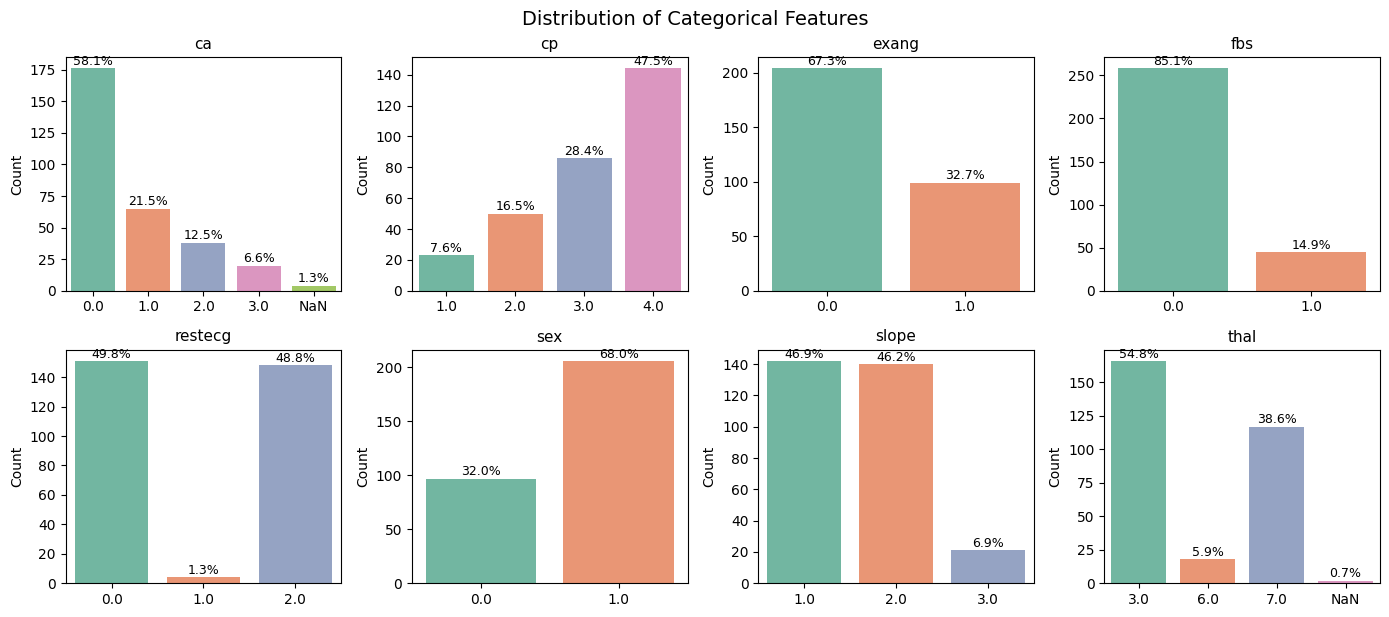

In [12]:
def sort_key(x):
        if x == 'NaN':
            return float('inf')
        try:
            return float(x)
        except ValueError:
            return float('inf')

cats = binary_categorical + nominal_categorical + ordinal_categorical

n_cols = 4
n_rows = (len(cats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(sorted(cats)):
    plot_data = df[col].fillna("NaN").astype(str)
    
    order = sorted(plot_data.unique(), key=sort_key)
    
    ax = axes[i]
    sns.countplot(x=plot_data, ax=ax, order=order, palette='Set2')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    
    total = len(df)
    for p in axes[i].patches:
        percentage = f'{100*p.get_height()/total:.1f}%'
        axes[i].annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.suptitle("Distribution of Categorical Features", fontsize=14, y=1.02)
plt.show()

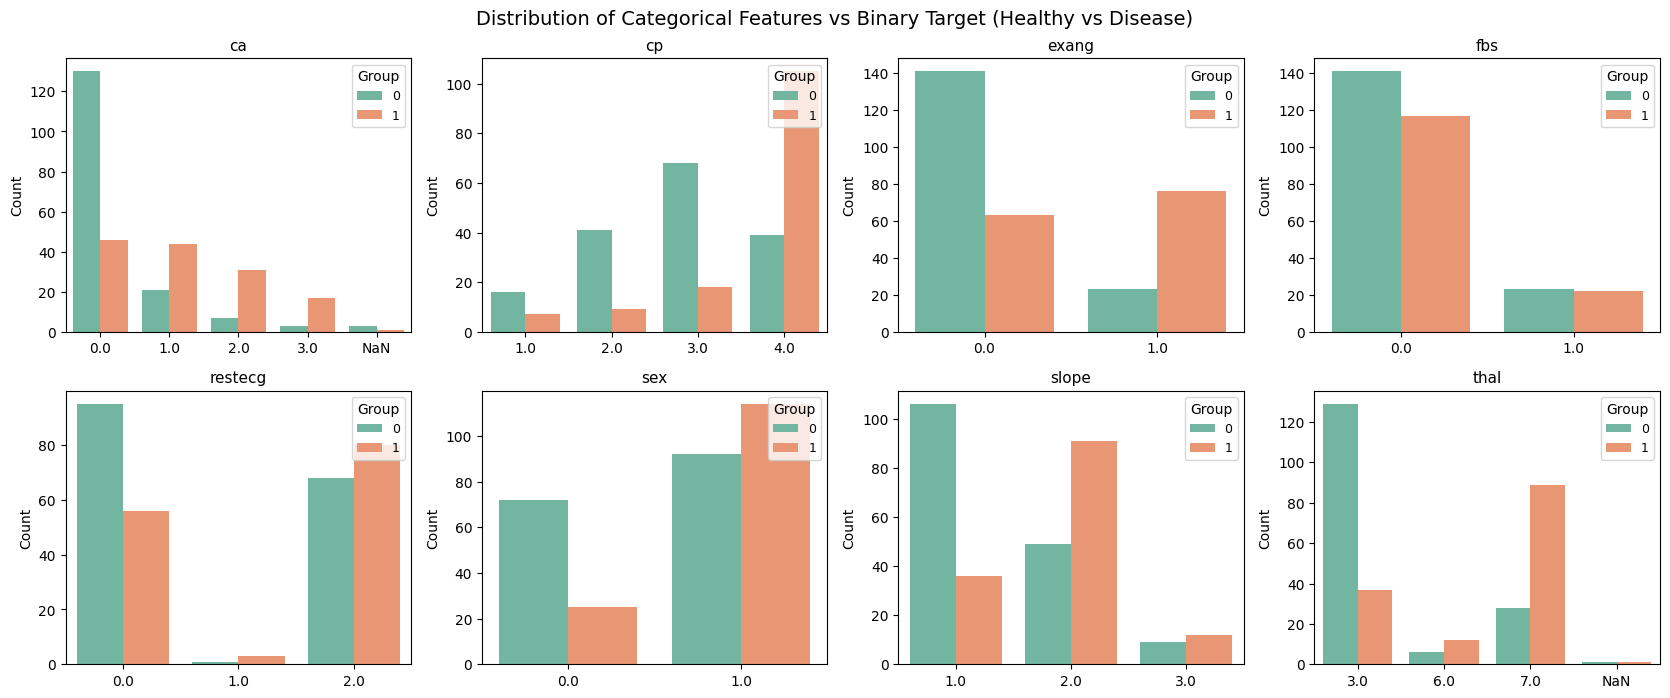

In [13]:
n_cols = 4
n_rows = (len(cats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.4))
axes = axes.flatten()

for i, col in enumerate(sorted(cats)):
    ax = axes[i]
    
    plot_data = df[[col]].copy()
    plot_data[col] = plot_data[col].fillna("NaN").astype(str)
    plot_data['Disease'] = y_binary
    
    unique_sorted = sorted(plot_data[col].unique(), key=sort_key)
    
    sns.countplot(data=plot_data, x=col, hue='Disease', ax=ax, order=unique_sorted, palette='Set2', dodge=True, hue_order=[0, 1])
    
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Group', labels=['0', '1'], fontsize=9, loc='upper right')

plt.tight_layout()
plt.suptitle("Distribution of Categorical Features vs Binary Target (Healthy vs Disease)", fontsize=14, y=1.02)
plt.show()

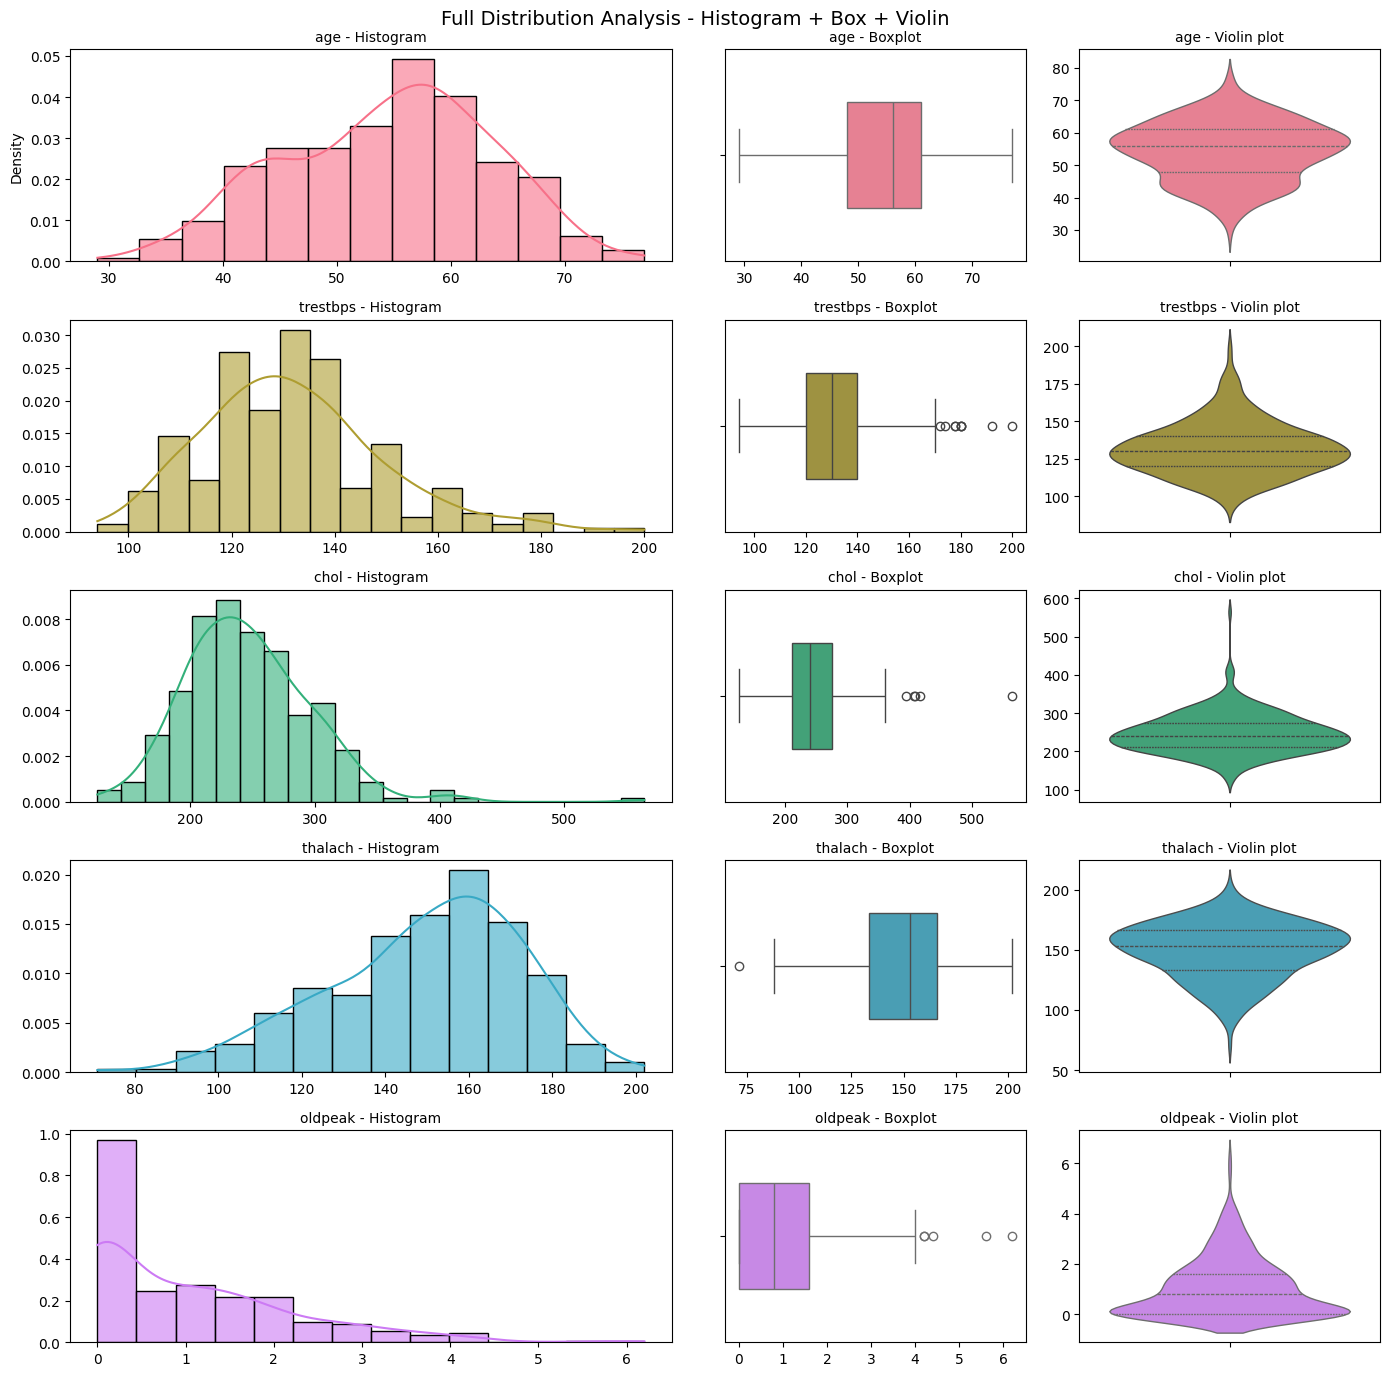

In [14]:
colors = sns.color_palette("husl", len(numerical))

fig, axes = plt.subplots(5, 3, figsize=(14, 14), gridspec_kw={'width_ratios': [2, 1, 1]})

for i, col in enumerate(numerical):
    current_color = colors[i]
    
    sns.histplot(df[col], kde=True, ax=axes[i, 0], stat='density', alpha=0.6, color=current_color)
    axes[i, 0].set_title(f'{col} - Histogram', fontsize=10)
    axes[i, 0].set_ylabel('Density' if i == 0 else '')
    axes[i, 0].set_xlabel('')

    sns.boxplot(x=df[col], ax=axes[i, 1], width=0.5, color=current_color)
    axes[i, 1].set_title(f'{col} - Boxplot', fontsize=10)
    axes[i, 1].set_ylabel('')
    axes[i, 1].set_xlabel('')

    sns.violinplot(y=df[col], ax=axes[i, 2], inner='quartile', linewidth=1, color=current_color)
    axes[i, 2].set_title(f'{col} - Violin plot', fontsize=10)
    axes[i, 2].set_ylabel('')
    axes[i, 2].set_xlabel('')

plt.suptitle("Full Distribution Analysis - Histogram + Box + Violin", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

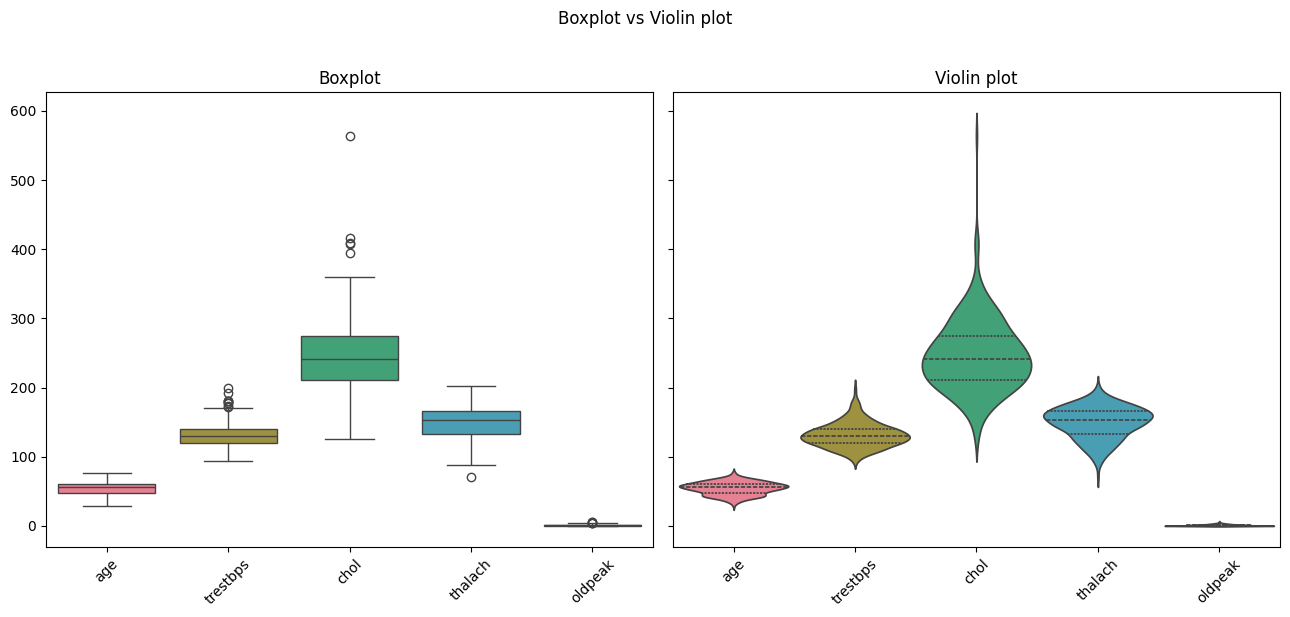

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)

colors = sns.color_palette("husl", len(numerical))

axes[0].set_title("Boxplot")
sns.boxplot(data=df[numerical], ax=axes[0], palette=colors)
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title("Violin plot")
sns.violinplot(data=df[numerical], ax=axes[1], inner="quartile", width=0.9, palette=colors)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Boxplot vs Violin plot", y=1.02)
plt.tight_layout()
plt.show()

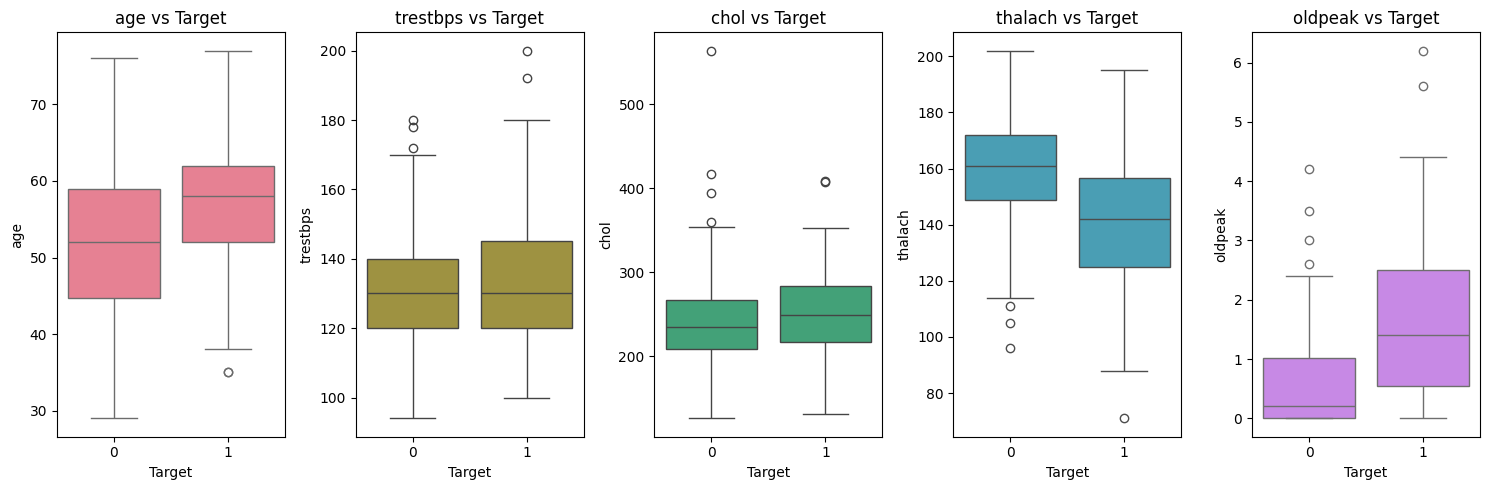

In [16]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical, 1):
    plt.subplot(1, 5, i)
    
    if 'sns' in globals():
        sns.boxplot(x=y_binary, y=df[col], color=colors[i-1])
    else:
        bp = plt.boxplot([df[col][y_binary==0].dropna(), df[col][y_binary==1].dropna()])
        # ręczne kolorowanie w matplotlib
        for box in bp['boxes']:
            box.set_facecolor(colors[i-1])
            box.set_alpha(0.7)
    
    plt.title(f'{col} vs Target')
    plt.xlabel('Target')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

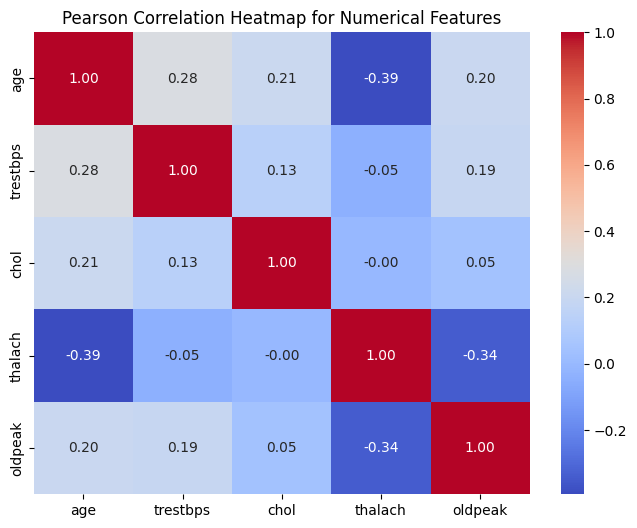

,Feature,Pearson Correlation with Target
0,oldpeak,0.424500
1,age,0.223100
2,trestbps,0.150800
3,chol,0.085200
4,thalach,-0.417200


,Feature,Chi-square,p-value,Significant (p < 0.05)
0,thal,83.289521,0.000000,Yes
1,cp,81.815770,0.000000,Yes
2,ca,71.843142,0.000000,Yes
3,exang,54.686435,0.000000,Yes
4,slope,45.784591,0.000000,Yes
5,sex,22.042561,0.000003,Yes
6,restecg,10.051541,0.006567,Yes
7,fbs,0.077095,0.781273,No


In [17]:
corr_df = df[numerical]
corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Heatmap for Numerical Features')
plt.show()

corr_df = df[numerical].copy()
corr_df['Target'] = y_binary
corr_matrix = corr_df.corr()['Target'].drop('Target').sort_values(ascending=False)

df_pearson = pd.DataFrame({
    'Feature': corr_matrix.index,
    'Pearson Correlation with Target': corr_matrix.values.round(4)
}).reset_index(drop=True)

display(df_pearson.style
    .set_caption("Pearson Correlations for Numerical Features vs Target")
    .set_properties(subset=['Feature'], **{'min-width': '100px'})
    .set_properties(subset=['Pearson Correlation with Target'], **{'min-width': '230px'})
)

chi_results = []
for cat in cats:
    if df[cat].nunique() > 1:
        crosstab = pd.crosstab(df[cat], y_binary)
        chi2, p, _, _ = chi2_contingency(crosstab)
        chi_results.append({
            'Feature': cat,
            'Chi-square': chi2,
            'p-value': p,
            'Significant (p < 0.05)': 'Yes' if p < 0.05 else 'No'
        })

df_chi = pd.DataFrame(chi_results)
df_chi = df_chi.sort_values('Chi-square', ascending=False).reset_index(drop=True)

display(df_chi.style
    .set_caption("Chi-square Test for Categorical Features vs Target")
    .set_properties(subset=['Feature'], **{'min-width': '100px'})
)

Results and Conclusions:

The UCI Cleveland Heart Disease dataset consists of 303 records with 14 columns (13 predictors + target). Data loading confirmed consistency: 303 rows x 14 columns, no empty strings, only minor missing values present (ca: 4 missing, thal: 2 missing; 98.0% of records fully complete).

The original target variable 'num' shows a multi-class distribution: class 0 (~54.1%), class 1 (~18.2%), class 2 (~11.9%), class 3 (~11.6%), class 4 (~4.3%). After binarization, the classes are nearly balanced: healthy ~54.1%, diseased ~45.9%.

Numerical features exhibit reasonable ranges with some outliers detected via IQR method (trestbps: 9, oldpeak: 5, chol: 5, thalach: 1, age: 0). Missing values are limited to two categorical features and affect only 6 records in total.

Categorical features show clear frequency imbalances (cp dominated by value 4, ca by 0, sex heavily skewed toward males, thal mostly 3 and 7).

Statistical tests indicate strong associations with the binary target for several features (particularly thal, cp, ca, exang, slope), while fbs shows no significant association (p = 0.781273).

Pearson correlations among numerical features are generally weak to moderate (strongest negative: age–thalach ≈ –0.39, thalach–oldpeak ≈ –0.34). The strongest linear relationships with the target are observed for oldpeak (~0.42) and thalach (~–0.42).

Overall, the dataset is small but clean, with mild class balance in the binary formulation and several features showing promising discriminative power already at the exploratory stage. Given the very small size (only 303 instances), no records will be removed due to missing values or outliers, and no aggressive feature selection by dropping columns is applied at this stage - each sample and each feature carries valuable information. These observations directly guide the choice of imputation strategy, encoding approach, scaling method and evaluation metrics in subsequent modeling steps.

=------------------------------------- Pipeline / Preprocessor / Data split -------------------------------------=

In this section I prepare data splits and build a modular preprocessing pipeline:

- Stratified train/test split (80/20, random_state=42, stratify on original multi-class target)
- Binary target created for both splits
- Printed basic info: samples & features count in train/test sets
- Displayed class distribution table (binary + multi-class, train vs test)

- Created make_preprocessor(...) function:
  - filters active features from predefined groups
  - Numerical: median imputation + StandardScaler
  - Nominal: mode imputation + OneHotEncoder (drop='first')
  - Binary: mode imputation
  - Ordinal: median imputation
  - Combined via ColumnTransformer (remainder='drop')

- Created build_pipelines(...) function:
  - generates full Pipeline for each model: preprocessor > classifier
  - returns dictionary of ready-to-use pipelines

This setup ensures consistent preprocessing and easy model comparison.

In [6]:
X_train, X_test, y_train_multi, y_test_multi = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
y_train_binary = (y_train_multi > 0).astype(int)
y_test_binary  = (y_test_multi > 0).astype(int)

In [7]:
print("="*70)
print("TRAINING SET")
print(f"Number of samples: {X_train.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

print("="*70)
print("TEST SET")
print(f"Number of samples: {X_test.shape[0]}")
print(f"Number of features: {X_test.shape[1]}")

class_distribution = pd.DataFrame({
    "Train set (binary)": y_train_binary.value_counts().sort_index(),
    "Test set (binary)": y_test_binary.value_counts().sort_index(),
    "Train set (multi-class)": y_train_multi.value_counts().sort_index(),
    "Test set (multi-class)": y_test_multi.value_counts().sort_index()
}).fillna(0).astype(int)

display(class_distribution)

TRAINING SET
Number of samples: 242
Number of features: 13
TEST SET
Number of samples: 61
Number of features: 13


,Train set (binary),Test set (binary),Train set (multi-class),Test set (multi-class)
num,,,,
0,131,33,131,33
1,111,28,44,11
2,0,0,29,7
3,0,0,28,7
4,0,0,10,3


In [8]:
def make_preprocessor(active_features, numerical, nominal_categorical, binary_categorical, ordinal_categorical):
    num = [c for c in numerical if c in active_features]
    nom = [c for c in nominal_categorical if c in active_features]
    bin_cat = [c for c in binary_categorical if c in active_features]
    ord_cat = [c for c in ordinal_categorical if c in active_features]

    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])

    nom_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])

    bin_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent"))])
    ord_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num),
            ("nom", nom_pipe, nom),
            ("bin", bin_pipe, bin_cat),
            ("ord", ord_pipe, ord_cat),
        ],
        remainder="drop"
    )

In [9]:
def build_pipelines(models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical):
    active_features = list(X_train.columns)
    preprocessor = make_preprocessor(active_features, numerical, nominal_categorical, binary_categorical, ordinal_categorical)

    pipelines = {}
    for name, clf in models.items():
        pipelines[name] = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ])
    return pipelines


Results and Conclusions:

The dataset was split into training (242 samples) and test set (61 samples) using an 80/20 stratified split based on the original multi-class target.

Number of features remains 13 in both sets.

Class distribution after split:
- Binary target:
  - Train: 131 healthy (0) vs 111 diseased (1)
  - Test:  33 healthy (0) vs 28 diseased (1)

- Multi-class target:
  - Train: 131 (0), 44 (1), 29 (2), 28 (3), 10 (4)
  - Test:  33 (0), 11 (1), 7 (2), 7 (3), 3 (4)

The stratification preserved the original class proportions in both splits, including the mild balance in the binary formulation.

Given the small dataset size, the preprocessing pipeline was designed to be consistent across all models and to safely handle the few missing values without discarding any records.

=------------------------------------- Training, evaluation and experiment utilities -------------------------------------=

In this section I implement reusable functions for model training, evaluation and experimentation:

- train_all(...):
  - fits each pipeline on the training set
  - optional threshold optimization on training set (based on F1-score over grid of probabilities 0.1–0.9)
  - computes predictions (with or without threshold)
  - calculates key metrics on test set: accuracy (train and test), precision, recall, F1, specificity, ROC AUC
  - collects results into DataFrame, sorts by test accuracy and returns it

- cross_validation(...):
  - performs repeated stratified k-fold cross-validation
  - rebuilds preprocessor + pipeline for each fold using build_pipelines
  - runs train_all on every fold (without displaying intermediate tables)
  - aggregates results across all folds/repeats
  - computes mean and standard deviation for each metric per model
  - displays final summary table (mean / std) sorted by mean test accuracy

- error_correlation_cv(...):
  - runs repeated stratified k-fold CV only on training data
  - fits each model on inner train split
  - records per-sample errors (misclassifications) on inner validation split
  - normalizes error counts by number of times each sample was in validation
  - builds DataFrame of per-sample error rates for each model
  - computes and displays error correlation matrix between models
  - calculates and prints average pairwise error correlation

These utilities enable:
- consistent training and threshold tuning
- robust performance estimation via repeated CV
- analysis of model agreement/disagreement via error correlations

In [10]:
def train_all(pipelines, X_train, X_test, y_train, y_test, display_table=True, threshold=False, threshold_grid=np.linspace(0.1, 0.9, 81)):
    results = []

    for name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)

        if threshold and hasattr(pipeline.named_steps["classifier"], "predict_proba"):
            y_train_proba = pipeline.predict_proba(X_train)[:, 1]
            
            scores = [f1_score(y_train, (y_train_proba >= t).astype(int)) for t in threshold_grid]
            best_threshold = threshold_grid[np.argmax(scores)]
            y_test_pred = (pipeline.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
            y_train_pred = (y_train_proba >= best_threshold).astype(int)
        else:
            y_train_pred = pipeline.predict(X_train)
            y_test_pred  = pipeline.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)

        precision = precision_score(y_test, y_test_pred, zero_division=0)
        recall    = recall_score(y_test, y_test_pred)
        f1        = f1_score(y_test, y_test_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            roc_auc = np.nan

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Recall": recall,
            "Specificity": specificity,
            "Precision": precision,
            "F1 score": f1,
            "ROC AUC": roc_auc
        })

    results_df = pd.DataFrame(results)
    if display_table:
        results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
        display(results_df)

    return results_df

In [11]:
def cross_validation(models_dict, X_full, y_full, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=10, n_repeats=5, random_state=42, summary_display=True, threshold=False):
    
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    
    all_results = []
    fold_counter = 0
    
    for train_idx, test_idx in cv.split(X_full, y_full):
        fold_counter += 1
        
        X_train = X_full.iloc[train_idx]
        X_test  = X_full.iloc[test_idx]
        y_train = y_full.iloc[train_idx]
        y_test  = y_full.iloc[test_idx]
        
        pipelines = build_pipelines(models_dict, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
        results_df = train_all(pipelines, X_train, X_test, y_train, y_test, display_table=False, threshold=threshold)
        
        results_df["Fold"] = fold_counter
        all_results.append(results_df)
    
    full_results = pd.concat(all_results, ignore_index=True)

    cols = ["Train Accuracy","Test Accuracy","Recall","Specificity","Precision","F1 score","ROC AUC"]
    mean_vals = full_results.groupby("Model")[cols].mean()
    std_vals  = full_results.groupby("Model")[cols].std(ddof=1)

    summary = mean_vals.round(4).astype(str) + " / std " + std_vals.round(4).astype(str)
    summary = summary.sort_values(by="Test Accuracy", ascending=False).reset_index()

    if summary_display:
        print(f"FINAL RESULTS - AVERAGE OF {n_repeats} VALIDATION REPETITIONS")
        display(summary)

    return summary, full_results

In [12]:
def error_correlation_cv(models, X_train, y_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=2, random_state=42):

    pipelines = build_pipelines(models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
    
    errors_dict = {name: np.zeros(len(X_train)) for name in pipelines.keys()}
    counts = np.zeros(len(X_train))
    
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        for name, pipe in pipelines.items():
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_val)
            errors_dict[name][val_idx] += (y_pred != y_val).astype(int)
        
        counts[val_idx] += 1
    
    for name in errors_dict.keys():
        errors_dict[name] = errors_dict[name] / counts
    
    errors_df = pd.DataFrame(errors_dict)
    
    corr_matrix = errors_df.corr()
    
    print("Error correlation matrix between models:\n")
    display(corr_matrix)
    
    mean_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
    print(f"\nAverage error correlation between models: {mean_corr:.3f}")
    
    return corr_matrix, mean_corr

Results and Conclusions:

The implemented utilities provide a robust and reproducible framework for:

- training multiple models with consistent preprocessing
- evaluating performance using clinically relevant metrics (accuracy, precision, recall, F1, specificity, ROC AUC)
- optional probability-threshold optimization to maximize F1-score
- reliable performance estimation through repeated stratified cross-validation (mean / std)
- analysis of model diversity via error correlation matrix

These tools allow for fair comparison of different classifiers, assessment of stability on small datasets and identification of models that may complement each other in an ensemble approach. All experiments remain fully reproducible thanks to fixed random states and modular pipeline design.

=------------------------------------- Baseline models -------------------------------------=

In this section I define and evaluate a diverse set of baseline classifiers using the prepared preprocessing pipeline and evaluation utilities.

The following models were included:
- Logistic Regression (L1 and L2 penalty)
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier
- CatBoost Classifier
- K-Nearest Neighbors Classifier
- Support Vector Machine
- Multi-Layer Perceptron
- AdaBoost Classifier (with shallow decision tree stumps)

All models were wrapped into scikit-learn Pipelines via build_pipelines function (preprocessor + classifier).

Evaluation steps performed:

- Single train/test evaluation:
  - fit on training set
  - predict on test set
  - compute accuracy (train and test), precision, recall, F1, specificity, ROC AUC
  - results displayed via train_all (sorted by test accuracy)

- Repeated stratified cross-validation (5 folds x 10 repeats):
  - first on training set only (X_train, y_train_binary)
  - second on full dataset (x, y_binary)
  - mean and standard deviation reported for each metric
  - final summary tables displayed (sorted by mean test accuracy)

- Error correlation analysis (5 folds x 10 repeats on training set):
  - per-sample error rates calculated across CV folds
  - pairwise error correlation matrix between models
  - average error correlation computed and printed

All experiments use fixed random_state=42 for full reproducibility.

In [35]:
models = {
    "Logistic Regression L1": LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    "Logistic Regression L2": LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), eval_metric='mlogloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=5000, random_state=42, early_stopping=True, n_iter_no_change=20, validation_fraction=0.1),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=100, learning_rate=0.5, random_state=42),
}

In [37]:
pipelines = build_pipelines(models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
_ = train_all(pipelines, X_train, X_test, y_train_binary, y_test_binary)

,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
1,Logistic Regression L2,0.863636,0.868852,0.857143,0.878788,0.857143,0.857143,0.922078
5,CatBoost,0.995868,0.868852,0.821429,0.909091,0.884615,0.851852,0.943723
9,AdaBoost,0.888430,0.852459,0.821429,0.878788,0.851852,0.836364,0.945887
3,Random Forest,1.000000,0.852459,0.857143,0.848485,0.827586,0.842105,0.930195
4,XGBoost,1.000000,0.852459,0.821429,0.878788,0.851852,0.836364,0.915584
6,KNN,0.859504,0.852459,0.785714,0.909091,0.880000,0.830189,0.924784
7,SVM,0.892562,0.852459,0.785714,0.909091,0.880000,0.830189,0.928571
0,Logistic Regression L1,0.863636,0.836066,0.821429,0.848485,0.821429,0.821429,0.923160
8,MLP,0.855372,0.836066,0.785714,0.878788,0.846154,0.814815,0.940476
2,Decision Tree,1.000000,0.721311,0.678571,0.757576,0.703704,0.690909,0.718074


In [38]:
summary, full = cross_validation(models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=True)

FINAL RESULTS - AVERAGE OF 10 VALIDATION REPETITIONS


,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,Logistic Regression L2,0.8731 / std 0.0137,0.843 / std 0.0475,0.78 / std 0.0746,0.8962 / std 0.0661,0.8698 / std 0.0711,0.8195 / std 0.0543,0.9072 / std 0.0335
1,Logistic Regression L1,0.8717 / std 0.0125,0.8385 / std 0.0488,0.7819 / std 0.075,0.8863 / std 0.0658,0.8584 / std 0.0711,0.8156 / std 0.0561,0.9063 / std 0.0354
2,AdaBoost,0.8944 / std 0.0136,0.8236 / std 0.0511,0.772 / std 0.0742,0.867 / std 0.0716,0.837 / std 0.0774,0.8003 / std 0.058,0.893 / std 0.0418
3,CatBoost,0.9958 / std 0.0025,0.8182 / std 0.0479,0.7727 / std 0.0722,0.8564 / std 0.0641,0.8245 / std 0.0685,0.7954 / std 0.0546,0.8922 / std 0.0388
4,SVM,0.8909 / std 0.0107,0.8153 / std 0.039,0.7343 / std 0.0672,0.8839 / std 0.0508,0.8462 / std 0.0566,0.784 / std 0.0471,0.8899 / std 0.0356
5,Random Forest,1.0 / std 0.0,0.8137 / std 0.0451,0.7621 / std 0.0846,0.8572 / std 0.0651,0.8243 / std 0.0667,0.7883 / std 0.0547,0.8912 / std 0.0409
6,KNN,0.8545 / std 0.0151,0.8071 / std 0.0517,0.7469 / std 0.08,0.8579 / std 0.0629,0.8201 / std 0.0675,0.7794 / std 0.0613,0.8551 / std 0.0442
7,XGBoost,1.0 / std 0.0,0.7943 / std 0.0521,0.7577 / std 0.0821,0.8251 / std 0.0684,0.7899 / std 0.0672,0.7707 / std 0.06,0.8685 / std 0.0446
8,MLP,0.7698 / std 0.0558,0.7497 / std 0.0677,0.7755 / std 0.0783,0.7279 / std 0.1162,0.7168 / std 0.0905,0.7407 / std 0.0638,0.8132 / std 0.072
9,Decision Tree,1.0 / std 0.0,0.7298 / std 0.0713,0.7127 / std 0.0927,0.7442 / std 0.0901,0.7067 / std 0.0844,0.7071 / std 0.0777,0.7285 / std 0.0712


In [39]:
summary, full = cross_validation(models, x, y_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=True)

FINAL RESULTS - AVERAGE OF 10 VALIDATION REPETITIONS


,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,Logistic Regression L2,0.8674 / std 0.0121,0.8363 / std 0.0425,0.7762 / std 0.0648,0.8873 / std 0.0615,0.8586 / std 0.0666,0.8128 / std 0.0486,0.9085 / std 0.032
1,Logistic Regression L1,0.8671 / std 0.012,0.8327 / std 0.0441,0.777 / std 0.0639,0.88 / std 0.0609,0.85 / std 0.0667,0.8096 / std 0.0504,0.9083 / std 0.0321
2,CatBoost,0.9965 / std 0.002,0.831 / std 0.0401,0.7878 / std 0.0698,0.8677 / std 0.0678,0.8406 / std 0.064,0.8101 / std 0.045,0.9038 / std 0.0332
3,AdaBoost,0.8864 / std 0.0158,0.829 / std 0.0408,0.7834 / std 0.0666,0.8676 / std 0.064,0.8388 / std 0.0608,0.8075 / std 0.0454,0.9029 / std 0.0311
4,SVM,0.8971 / std 0.0107,0.8261 / std 0.0394,0.7497 / std 0.0685,0.8909 / std 0.0533,0.8572 / std 0.0594,0.7974 / std 0.0489,0.8949 / std 0.0344
5,Random Forest,1.0 / std 0.0,0.8201 / std 0.0436,0.7706 / std 0.0695,0.8622 / std 0.064,0.8305 / std 0.0651,0.7968 / std 0.0502,0.9007 / std 0.0357
6,KNN,0.8668 / std 0.0134,0.8125 / std 0.044,0.7742 / std 0.0768,0.8452 / std 0.0565,0.8121 / std 0.0591,0.7902 / std 0.0522,0.87 / std 0.0397
7,XGBoost,1.0 / std 0.0,0.8049 / std 0.05,0.7583 / std 0.0818,0.8445 / std 0.0651,0.8092 / std 0.0642,0.78 / std 0.0586,0.8777 / std 0.0334
8,MLP,0.7936 / std 0.0481,0.766 / std 0.0565,0.7923 / std 0.0823,0.7442 / std 0.1238,0.7367 / std 0.084,0.7573 / std 0.049,0.8455 / std 0.0515
9,Decision Tree,1.0 / std 0.0,0.7561 / std 0.0511,0.7332 / std 0.0867,0.7757 / std 0.0792,0.7404 / std 0.0697,0.7329 / std 0.0574,0.7544 / std 0.0513


In [40]:
corr_matrix, mean_corr = error_correlation_cv(models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42)

Error correlation matrix between models:



,Logistic Regression L1,Logistic Regression L2,Decision Tree,Random Forest,XGBoost,CatBoost,KNN,SVM,MLP,AdaBoost
Logistic Regression L1,1.000000,0.984876,0.641825,0.847855,0.761283,0.836636,0.767790,0.840459,0.454301,0.878482
Logistic Regression L2,0.984876,1.000000,0.618641,0.825917,0.738293,0.819116,0.748733,0.853854,0.461655,0.860402
Decision Tree,0.641825,0.618641,1.000000,0.776992,0.791011,0.720113,0.647716,0.622282,0.362665,0.721114
Random Forest,0.847855,0.825917,0.776992,1.000000,0.894384,0.917392,0.788986,0.804688,0.500803,0.900223
XGBoost,0.761283,0.738293,0.791011,0.894384,1.000000,0.895380,0.708105,0.697400,0.432089,0.838822
CatBoost,0.836636,0.819116,0.720113,0.917392,0.895380,1.000000,0.769574,0.801531,0.509240,0.882157
KNN,0.767790,0.748733,0.647716,0.788986,0.708105,0.769574,1.000000,0.842783,0.562740,0.773489
SVM,0.840459,0.853854,0.622282,0.804688,0.697400,0.801531,0.842783,1.000000,0.563608,0.776745
MLP,0.454301,0.461655,0.362665,0.500803,0.432089,0.509240,0.562740,0.563608,1.000000,0.492159
AdaBoost,0.878482,0.860402,0.721114,0.900223,0.838822,0.882157,0.773489,0.776745,0.492159,1.000000



Average error correlation between models: 0.732


Results and Conclusions:

On the hold-out test set (61 samples) the top performers achieved ~86.9% accuracy:
- Logistic Regression L2: ~86.9% accuracy, ~85.7% recall, ~92.2% ROC AUC
- CatBoost: ~86.9% accuracy, ~82.1% recall, ~94.4% ROC AUC
- AdaBoost, Random Forest, XGBoost, KNN, SVM: ~85.2% accuracy
- Decision Tree showed clear overfitting (100% train, ~72.1% test)

Repeated CV on training subset (mean / std) confirmed similar ranking:
- Logistic Regression L2: 84.3% mean test accuracy and std ~4.8%
- CatBoost, AdaBoost, SVM, Random Forest: ~81–82%
- Decision Tree and MLP lowest (~73–75%)

CV on full dataset (303 samples) gave slightly higher and more stable estimates:
- Logistic Regression L2 ~83.6% mean accuracy and std ~4.3%
- CatBoost and AdaBoost ~83.0–83.1%
- Decision Tree again weakest (~75.6%)

Error correlation matrix revealed moderate to high agreement among tree-based/boosting models (0.78–0.92), while MLP showed lowest correlations with others (~0.43–0.56), suggesting potential complementarity in ensembles.

Linear models performed surprisingly well and stably on this small, tabular dataset, often outperforming more complex models in repeated CV. This serves as a strong baseline for further tuning and possible ensemble construction.

=------------------------------------- Tuning of selected models -------------------------------------=

In this section I performed hyperparameter optimization for the most promising baseline models using Optuna and repeated stratified cross-validation.

Selected models for tuning:
- Logistic Regression
- Support Vector Machine (RBF kernel)
- CatBoost Classifier
- Random Forest Classifier
- AdaBoost Classifier (with decision tree base estimator)

For each model I defined and executed tune_model_optuna(...) function:
- builds full pipeline (preprocessor + classifier) using build_pipelines
- uses RepeatedStratifiedKFold (5 folds x 10 repeats, random_state=42) as inner CV
- employs OptunaSearchCV with 1000 trials
- optimizes for ROC AUC score
- prints best CV ROC AUC score and the corresponding best parameters

All tuning runs were performed on the training set (X_train, y_train_binary) with fixed random_state=42 for reproducibility.

In [ ]:
def tune_model_optuna(model, params, X_train, Y_train, target):
    inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

    pipelines = build_pipelines({"Model": model}, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
    pipeline = pipelines["Model"]

    optuna_search = OptunaSearchCV(estimator=pipeline, param_distributions=params, cv=inner_cv, n_trials=1000, scoring=target, random_state=42, verbose=0)

    optuna_search.fit(X_train, Y_train)

    print("\n=== Best Parameters ===")
    print(f"{target} (CV mean): {optuna_search.best_score_:.4f}")
    print("Parameters:")
    for k, v in optuna_search.best_params_.items():
        print(f"  {k:35} : {v}")

In [40]:
tune_model_optuna(
    model = LogisticRegression(max_iter=10000, solver='saga', random_state=42),
    params = {
        'classifier__C': optuna.distributions.FloatDistribution(1e-4, 1e4, log=True),
        'classifier__penalty': optuna.distributions.CategoricalDistribution(["l1", "l2"]),
        'classifier__class_weight': optuna.distributions.CategoricalDistribution([None, 'balanced']),
        'classifier__tol': optuna.distributions.FloatDistribution(1e-5, 1e-2, log=True)
    },
    X_train = X_train,
    Y_train = y_train_binary,
    target = "roc_auc"
)


=== Best Parameters ===
Roc_Auc (CV mean): 0.9098
Parameters:
  classifier__C                       : 0.18855470366314864
  classifier__penalty                 : l2
  classifier__class_weight            : balanced
  classifier__tol                     : 3.481335579057248e-05


In [41]:
tune_model_optuna(
    model = SVC(kernel='rbf', probability=True, random_state=42),
    params = {
        'classifier__C': optuna.distributions.FloatDistribution(1e-2, 1e3, log=True),
        'classifier__gamma': optuna.distributions.FloatDistribution(1e-4, 1.0, log=True),
        'classifier__class_weight': optuna.distributions.CategoricalDistribution([None, 'balanced']),
        'classifier__tol': optuna.distributions.FloatDistribution(1e-5, 1e-2, log=True),
    },
    X_train = X_train,
    Y_train = y_train_binary,
    target = "roc_auc"
)


=== Best Parameters ===
Roc_Auc (CV mean): 0.9074
Parameters:
  classifier__C                       : 29.65785465535794
  classifier__gamma                   : 0.0008617988546732021
  classifier__class_weight            : balanced
  classifier__tol                     : 0.0001918332000859227


In [42]:
tune_model_optuna(
    model = CatBoostClassifier(verbose=0, random_state=42),
    params = {
    'classifier__iterations': optuna.distributions.IntDistribution(300, 1500),
    'classifier__learning_rate': optuna.distributions.FloatDistribution(0.02, 0.2, log=True),
    'classifier__depth': optuna.distributions.IntDistribution(4, 8),
    'classifier__l2_leaf_reg': optuna.distributions.FloatDistribution(1.0, 10.0, log=True),
    'classifier__random_strength': optuna.distributions.FloatDistribution(0.0, 5.0),
    'classifier__scale_pos_weight': optuna.distributions.FloatDistribution(1.0, 5.0),
    'classifier__grow_policy': optuna.distributions.CategoricalDistribution(['SymmetricTree', 'Depthwise']),
},
    X_train = X_train,
    Y_train = y_train_binary,
    target = "roc_auc"
)


=== Best Parameters ===
Roc_Auc (CV mean): 0.9044
Parameters:
  classifier__iterations              : 302
  classifier__learning_rate           : 0.024349152482303415
  classifier__depth                   : 4
  classifier__l2_leaf_reg             : 9.61469166175666
  classifier__random_strength         : 3.529629611699919
  classifier__scale_pos_weight        : 4.920144086369598
  classifier__grow_policy             : SymmetricTree


In [43]:
tune_model_optuna(
    model = RandomForestClassifier(random_state=42),
    params = {
    'classifier__n_estimators':     optuna.distributions.IntDistribution(100, 1500),
    'classifier__max_depth':        optuna.distributions.IntDistribution(3, 20, log=False),
    'classifier__min_samples_split': optuna.distributions.IntDistribution(2, 20),
    'classifier__min_samples_leaf':  optuna.distributions.IntDistribution(1, 10),
    'classifier__max_features':     optuna.distributions.CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__bootstrap':        optuna.distributions.CategoricalDistribution([True, False]),
    'classifier__class_weight':     optuna.distributions.CategoricalDistribution([None, 'balanced', 'balanced_subsample']),
},
    X_train = X_train,
    Y_train = y_train_binary,
    target = "roc_auc"
)


=== Best Parameters ===
Roc_Auc (CV mean): 0.9015
Parameters:
  classifier__n_estimators            : 104
  classifier__max_depth               : 12
  classifier__min_samples_split       : 12
  classifier__min_samples_leaf        : 4
  classifier__max_features            : log2
  classifier__bootstrap               : True
  classifier__class_weight            : None


In [ ]:
tune_model_optuna(
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    params = {
    'classifier__n_estimators':      optuna.distributions.IntDistribution(100, 800),
    'classifier__learning_rate':     optuna.distributions.FloatDistribution(0.01, 1.0, log=True),

    'classifier__estimator__max_depth':          optuna.distributions.IntDistribution(1, 5),
    'classifier__estimator__min_samples_split':  optuna.distributions.IntDistribution(4, 40),
    'classifier__estimator__min_samples_leaf':   optuna.distributions.IntDistribution(4, 30),
    'classifier__estimator__max_features':       optuna.distributions.CategoricalDistribution([None, 'sqrt', 'log2']),
},
    X_train = X_train,
    Y_train = y_train_binary,
    target = "roc_auc"
)


=== Best Parameters ===
Roc_Auc (CV mean): 0.9021
Parameters:
  classifier__n_estimators            : 351
  classifier__learning_rate           : 0.012567906035866895
  classifier__estimator__max_depth    : 1
  classifier__estimator__min_samples_split : 24
  classifier__estimator__min_samples_leaf : 30
  classifier__estimator__max_features : sqrt


Results and Conclusions:

Hyperparameter tuning was performed using ROC AUC as the primary scoring metric, since it provides a robust, threshold-independent assessment of model discrimination ability, which is particularly suitable for the nearly balanced binary target in this dataset.

Subsequently, for each tuned model, an optimal decision threshold was selected on the training set probabilities to maximize F1-score, thereby tailoring the final predictions to better balance precision and recall in the medical classification context.

All tuning runs were performed exclusively on the training set (X_train, y_train_binary) with fixed random_state=42 for reproducibility.  
The hold-out test set was never used during the optimization process to avoid positive bias and data leakage, ensuring that reported final performance on test data remains an unbiased estimate of generalization.

This step aimed to enhance the generalization of the strongest baseline models (Logistic Regression, SVM, CatBoost, Random Forest, AdaBoost).

Due to the small dataset size, particular emphasis was placed on regularization, class weighting, and constraints on tree depth to mitigate overfitting risk during optimization.

=------------------------------------- Tuned models -------------------------------------=

In this section I evaluated the tuned versions of the most promising models using the best hyperparameters found in the previous Optuna optimization step.

Selected tuned models and their final parameters:
- CatBoost (tuned): iterations 302, learning_rate ~0.0243, depth 4, l2_leaf_reg ~9.61, random_strength ~3.53, scale_pos_weight ~4.92, grow_policy "SymmetricTree"
- SVM (tuned): C ~29.66, gamma ~0.00086, tol ~0.00019, class_weight "balanced"
- Logistic Regression L2 (tuned): C ~0.189, penalty "l2", class_weight "balanced", tol ~3.48e-05
- Random Forest (tuned): n_estimators 104, max_depth 12, min_samples_split 12, min_samples_leaf 4, max_features "log2", bootstrap True, class_weight None
- AdaBoost (tuned): n_estimators 351, learning_rate ~0.0126; base estimator: max_depth 1, min_samples_split 24, min_samples_leaf 30, max_features "sqrt"

All models were wrapped into full Pipelines (preprocessor + classifier) via build_pipelines(...) function.

Evaluation was performed using the same utilities as for baselines:

- Single train/test split evaluation with optional probability threshold optimization (maximizing F1 on training probabilities)
- Repeated stratified cross-validation (5 folds x 10 repeats):
  - first on training subset only
  - second on full dataset
- Error correlation analysis (5 folds x 10 repeats on training data)

Cross-validation results carry slight positive bias because hyperparameter tuning was performed using the same data splits.

All runs used random_state=42 for full reproducibility.

In [57]:
tuned_models = {
    "CatBoost (tuned)": CatBoostClassifier( iterations=302, learning_rate=0.024349152482303415, depth=4, l2_leaf_reg=9.61469166175666, random_strength=3.529629611699919, scale_pos_weight=4.920144086369598, grow_policy="SymmetricTree", verbose=0, random_state=42),
    "SVM (tuned)": SVC(kernel="rbf", C=29.65785465535794, gamma=0.0008617988546732021, tol=0.0001918332000859227, class_weight="balanced", probability=True, random_state=42),
    "Logistic Regression L2 (tuned)": LogisticRegression(C=0.18855470366314864, penalty="l2", class_weight="balanced", tol=3.481335579057248e-05, solver="saga", max_iter=3000, random_state=42),
    "Random Forest (tuned)": RandomForestClassifier(n_estimators=104, max_depth=12, min_samples_split=12, min_samples_leaf=4, max_features="log2", bootstrap=True, class_weight=None, random_state=42, n_jobs=-1),
    "AdaBoost (tuned)": AdaBoostClassifier(n_estimators=351, learning_rate=0.012567906035866895, estimator=DecisionTreeClassifier(max_depth=1, min_samples_split=24, min_samples_leaf=30, max_features="sqrt", random_state=42), random_state=42)
}

In [58]:
pipelines = build_pipelines(tuned_models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
_ = train_all(pipelines, X_train, X_test, y_train_binary, y_test_binary, display_table=True, threshold=True)

,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,CatBoost (tuned),0.917355,0.901639,0.928571,0.878788,0.866667,0.896552,0.952381
4,AdaBoost (tuned),0.867769,0.868852,0.821429,0.909091,0.884615,0.851852,0.948052
3,Random Forest (tuned),0.929752,0.868852,0.928571,0.818182,0.812500,0.866667,0.949134
2,Logistic Regression L2 (tuned),0.876033,0.852459,0.857143,0.848485,0.827586,0.842105,0.933983
1,SVM (tuned),0.884298,0.852459,0.785714,0.909091,0.880000,0.830189,0.931818


In [59]:
summary, full = cross_validation(tuned_models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=True, threshold=True)

FINAL RESULTS - AVERAGE OF 10 VALIDATION REPETITIONS


,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,Logistic Regression L2 (tuned),0.8794 / std 0.0112,0.8313 / std 0.0554,0.8218 / std 0.0728,0.8396 / std 0.0905,0.8208 / std 0.0801,0.8176 / std 0.0549,0.9098 / std 0.031
1,SVM (tuned),0.8782 / std 0.0114,0.8293 / std 0.0467,0.818 / std 0.0723,0.8389 / std 0.0819,0.8188 / std 0.075,0.8148 / std 0.0483,0.9073 / std 0.0321
2,CatBoost (tuned),0.9325 / std 0.0084,0.8227 / std 0.0495,0.8154 / std 0.0881,0.8289 / std 0.0714,0.8067 / std 0.0672,0.8074 / std 0.0552,0.9044 / std 0.0401
3,AdaBoost (tuned),0.8684 / std 0.0134,0.8181 / std 0.0528,0.8135 / std 0.0864,0.8218 / std 0.0912,0.8037 / std 0.0816,0.8038 / std 0.0559,0.9021 / std 0.0389
4,Random Forest (tuned),0.9313 / std 0.0103,0.8041 / std 0.0517,0.8072 / std 0.0674,0.8015 / std 0.0783,0.7805 / std 0.073,0.7911 / std 0.0534,0.9015 / std 0.0363


In [60]:
summary, full = cross_validation(tuned_models, x, y_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=True, threshold=True)

FINAL RESULTS - AVERAGE OF 10 VALIDATION REPETITIONS


,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,AdaBoost (tuned),0.8738 / std 0.0132,0.8465 / std 0.0404,0.8439 / std 0.0676,0.8489 / std 0.0735,0.8317 / std 0.0655,0.8347 / std 0.0418,0.9116 / std 0.0339
1,CatBoost (tuned),0.9259 / std 0.0106,0.8307 / std 0.0442,0.8441 / std 0.0697,0.8197 / std 0.0799,0.8054 / std 0.0696,0.8208 / std 0.044,0.9126 / std 0.031
2,SVM (tuned),0.874 / std 0.0112,0.8264 / std 0.0542,0.8085 / std 0.081,0.8416 / std 0.075,0.817 / std 0.0722,0.8099 / std 0.0604,0.9058 / std 0.0338
3,Logistic Regression L2 (tuned),0.8691 / std 0.0138,0.8251 / std 0.0464,0.8179 / std 0.0781,0.8312 / std 0.0683,0.8087 / std 0.0629,0.8104 / std 0.0514,0.9114 / std 0.0324
4,Random Forest (tuned),0.9292 / std 0.0084,0.8192 / std 0.0469,0.8309 / std 0.0742,0.8094 / std 0.0759,0.792 / std 0.0634,0.8081 / std 0.0487,0.9106 / std 0.0319


In [61]:
corr_matrix, mean_corr = error_correlation_cv(tuned_models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42)

Error correlation matrix between models:



,CatBoost (tuned),SVM (tuned),Logistic Regression L2 (tuned),Random Forest (tuned),AdaBoost (tuned)
CatBoost (tuned),1.000000,0.336197,0.417695,0.388280,0.271258
SVM (tuned),0.336197,1.000000,0.945529,0.866059,0.809288
Logistic Regression L2 (tuned),0.417695,0.945529,1.000000,0.856193,0.771928
Random Forest (tuned),0.388280,0.866059,0.856193,1.000000,0.900938
AdaBoost (tuned),0.271258,0.809288,0.771928,0.900938,1.000000



Average error correlation between models: 0.656


Results and Conclusions:

On the hold-out test set (61 samples) the best tuned models achieved:
- CatBoost (tuned): ~90.2% accuracy, ~92.9% recall, ~87.9% specificity, ~86.7% precision, ~89.7% F1, ~95.2% ROC AUC
- AdaBoost: ~86.9% accuracy, ~82.1% recall, ~90.9% specificity, ~88.5% precision, ~85.2% F1, ~94.8% ROC AUC
- Random Forest: ~86.9% accuracy, ~92.9% recall, ~81.8% specificity, ~81.3% precision, ~86.7% F1, ~94.9% ROC AUC
- Logistic Regression L2 (tuned) and SVM (tuned): ~85.2% accuracy

Repeated CV on training subset (mean / std):
- Logistic Regression L2 (tuned) and SVM (tuned) highest mean test accuracy ~82.9–83.1% (std ~4.7–5.5%)
- CatBoost (tuned): ~82.3% (std ~4.9%)
- AdaBoost (tuned): ~81.8% (std ~5.3%)
- Random Forest (tuned): ~80.4% (std ~5.2%)

Repeated CV on full dataset (303 samples) showed slightly higher estimates:
- AdaBoost (tuned): highest mean test accuracy ~84.7% (std ~4.0%)
- CatBoost (tuned): ~83.1% (std ~4.4%)
- SVM (tuned): ~82.6% (std ~5.4%)
- Logistic Regression L2 (tuned): ~82.5% (std ~4.6%)
- Random Forest (tuned): ~81.9% (std ~4.7%)

Error correlation matrix among tuned models (on training data):
- Highest correlations: SVM and Logistic Regression L2 (~0.95), Random Forest and AdaBoost (~0.90), Random Forest and SVM/Logistic (~0.86–0.87)
- Moderate: SVM/AdaBoost/Logistic (~0.77–0.81)
- Lowest: CatBoost with others (~0.27–0.42), especially with AdaBoost (~0.27)

Cross-validation results may contain slight positive bias, as hyperparameter tuning was performed using nested CV on overlapping data splits from the training set. The hold-out test set remained completely unseen during tuning.

Tuned models generally improved over their baseline versions, particularly CatBoost and AdaBoost on the hold-out test set and full-data CV. The low error correlation of CatBoost with linear models and AdaBoost suggests potential for complementary ensembling.

=------------------------------------- Risk Stratification with the Final Model -------------------------------------=

In this section the final selected model - CatBoost (tuned) – was fitted on the entire training set and used to generate risk stratification on the hold-out test set.

The following steps were performed:
- Built and fitted the pipeline on X_train / y_train_binary
- Generated predicted probabilities for X_test
- Stratified patients into risk groups using pd.cut:
  - Low risk: < 0.40
  - Medium risk: 0.40–0.70
  - High risk: > 0.70
- Created summary table per group (count, disease cases, rate, percent of total)
- Calculated disease rate in top 20% highest-risk patients
- Visualized probability distribution by true label (histogram)

All operations were performed on the hold-out test set (61 samples) to provide an unbiased assessment of risk stratification performance.

,Count,Disease_cases,Disease_rate,Percent_of_total
Risk_group,,,,
Low,15,0,0.00%,24.59%
Medium,14,2,14.29%,22.95%
High,32,26,81.25%,52.46%


Disease rate in top 20% highest-risk patients: 91.67%


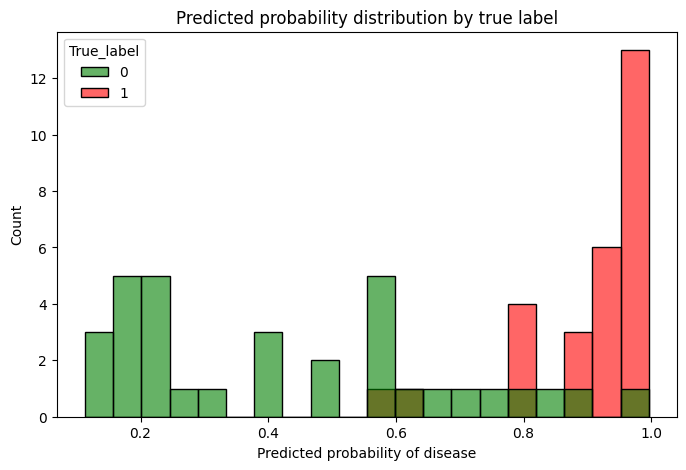

In [35]:
final_model = tuned_models["CatBoost (tuned)"]

final_pipeline = build_pipelines({"Model": final_model}, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)["Model"]

final_pipeline.fit(X_train, y_train_binary)

y_test_proba = final_pipeline.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    "True_label": y_test_binary,
    "Predicted_probability": y_test_proba
})

risk_df["Risk_group"] = pd.cut(
    risk_df["Predicted_probability"],
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

risk_table = risk_df.groupby("Risk_group").agg(
    Count=("True_label", "size"),
    Disease_cases=("True_label", "sum"),
    Disease_rate=("True_label", "mean")
)
risk_table["Percent_of_total"] = 100 * risk_table["Count"] / len(risk_df)

display(risk_table.style
        .format({"Disease_rate": "{:.2%}", "Percent_of_total": "{:.2f}%"})
        .set_caption("Risk group summary")
)

top_20 = risk_df.nlargest(int(0.2 * len(risk_df)), "Predicted_probability")
top_20_rate = top_20["True_label"].mean()
print(f"Disease rate in top 20% highest-risk patients: {top_20_rate:.2%}")

plt.figure(figsize=(8,5))
sns.histplot(risk_df, x="Predicted_probability", hue="True_label", bins=20, kde=False, palette={0:"green",1:"red"}, alpha=0.6)
plt.title("Predicted probability distribution by true label")
plt.xlabel("Predicted probability of disease")
plt.ylabel("Count")
plt.show()

Results and Conclusions:

High-risk group (>0.70) contained 81.25% diseased patients and 52.46% of the test set.

The top 20% of patients with the highest predicted risk had a disease rate of 91.67%, confirming excellent ability to identify individuals at highest risk.

The probability histogram showed good separation: diseased patients concentrated in higher probability bins (mostly >0.8), while healthy patients dominated lower bins.

These results demonstrate that the final model not only achieves high classification performance but also generates clinically meaningful risk scores for potential prioritization or targeted interventions.

=------------------------------------- Comparison of baseline model and tuned models -------------------------------------=

In this section a direct head-to-head comparison was made between the original baseline models and their tuned versions.

Baseline models used:
- CatBoost
- SVM (RBF kernel)
- Logistic Regression L2
- Random Forest
- AdaBoost (with shallow stumps)

Tuned models used (with best Optuna parameters):
- CatBoost (tuned)
- SVM (tuned)
- Logistic Regression L2 (tuned)
- Random Forest (tuned)
- AdaBoost (tuned)

All models were wrapped into Pipelines via build_pipelines function.

The comparison included three evaluation scenarios:
- Single hold-out test set evaluation (61 samples)
  - baselines without threshold optimization
  - tuned models with probability threshold optimization (F1 maximization on training probabilities)
  - results concatenated into one table, sorted by F1-score and displayed

- Repeated stratified cross-validation (5 folds x 10 repeats) on training subset only
  - baselines without threshold
  - tuned models with threshold optimization
  - mean / std tables concatenated, sorted by mean F1-score and displayed

- Repeated stratified cross-validation (5 folds x 10 repeats) on full dataset (303 samples)
  - same configuration as above
  - mean / std tables concatenated, sorted by mean F1-score and displayed

CV results for tuned models carry slight positive bias due to hyperparameter tuning on overlapping data splits from the training set. Baseline models were not tuned, so their CV scores are unbiased.

All experiments used random_state=42 for reproducibility.

In [46]:
base_models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42),
    "Logistic Regression L2": LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), n_estimators=100, learning_rate=0.5, random_state=42)
}

In [47]:
tuned_models = {
    "CatBoost (tuned)": CatBoostClassifier( iterations=302, learning_rate=0.024349152482303415, depth=4, l2_leaf_reg=9.61469166175666, random_strength=3.529629611699919, scale_pos_weight=4.920144086369598, grow_policy="SymmetricTree", verbose=0, random_state=42),
    "SVM (tuned)": SVC(kernel="rbf", C=29.65785465535794, gamma=0.0008617988546732021, tol=0.0001918332000859227, class_weight="balanced", probability=True, random_state=42),
    "Logistic Regression L2 (tuned)": LogisticRegression(C=0.18855470366314864, penalty="l2", class_weight="balanced", tol=3.481335579057248e-05, solver="saga", max_iter=3000, random_state=42),
    "Random Forest (tuned)": RandomForestClassifier(n_estimators=104, max_depth=12, min_samples_split=12, min_samples_leaf=4, max_features="log2", bootstrap=True, class_weight=None, random_state=42, n_jobs=-1),
    "AdaBoost (tuned)": AdaBoostClassifier(n_estimators=351, learning_rate=0.012567906035866895, estimator=DecisionTreeClassifier(max_depth=1, min_samples_split=24, min_samples_leaf=30, max_features="sqrt", random_state=42), random_state=42)
}

In [48]:
pipelines = build_pipelines(base_models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
base = train_all(pipelines, X_train, X_test, y_train_binary, y_test_binary, display_table=False)

pipelines = build_pipelines(tuned_models, X_train, numerical, nominal_categorical, binary_categorical, ordinal_categorical)
tune = train_all(pipelines, X_train, X_test, y_train_binary, y_test_binary, display_table=False, threshold=True)

df_combined = pd.concat([base, tune], ignore_index=True)
df_combined = df_combined.sort_values(by='F1 score', ascending=False).reset_index(drop=True)
display(df_combined.style
        .set_caption("Comparison of Baseline and Tuned Models - Evaluation on Held-Out Test Set")
)

,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,CatBoost (tuned),0.917355,0.901639,0.928571,0.878788,0.866667,0.896552,0.952381
1,Random Forest (tuned),0.929752,0.868852,0.928571,0.818182,0.812500,0.866667,0.949134
2,Logistic Regression L2,0.863636,0.868852,0.857143,0.878788,0.857143,0.857143,0.922078
3,CatBoost,0.995868,0.868852,0.821429,0.909091,0.884615,0.851852,0.943723
4,AdaBoost (tuned),0.867769,0.868852,0.821429,0.909091,0.884615,0.851852,0.948052
5,Logistic Regression L2 (tuned),0.876033,0.852459,0.857143,0.848485,0.827586,0.842105,0.933983
6,Random Forest,1.000000,0.852459,0.857143,0.848485,0.827586,0.842105,0.930195
7,AdaBoost,0.888430,0.852459,0.821429,0.878788,0.851852,0.836364,0.945887
8,SVM,0.892562,0.852459,0.785714,0.909091,0.880000,0.830189,0.928571
9,SVM (tuned),0.884298,0.852459,0.785714,0.909091,0.880000,0.830189,0.931818


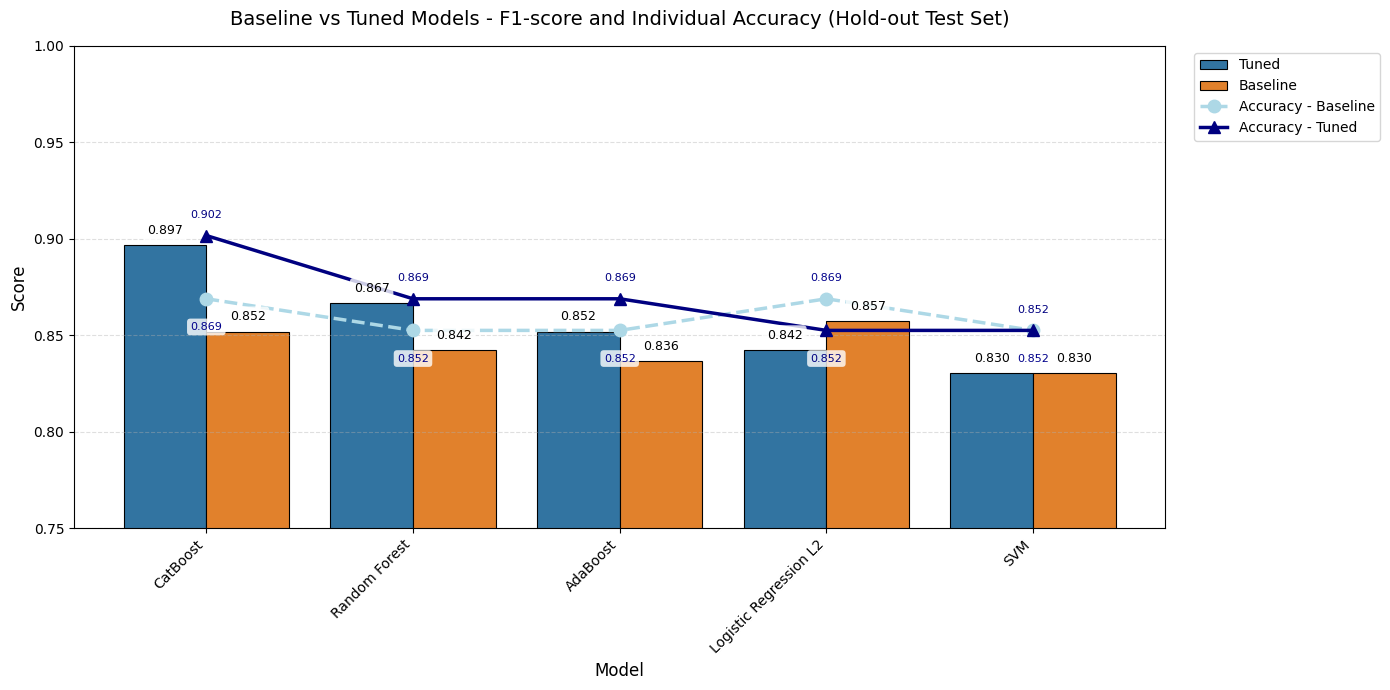

In [83]:
data = {
    'Model': [
        'CatBoost (tuned)', 'Random Forest (tuned)', 'Logistic Regression L2',
        'CatBoost', 'AdaBoost (tuned)', 'Logistic Regression L2 (tuned)',
        'Random Forest', 'AdaBoost', 'SVM', 'SVM (tuned)'
    ],
    'F1 score': [
        0.896552, 0.866667, 0.857143, 0.851852, 0.851852, 0.842105,
        0.842105, 0.836364, 0.830189, 0.830189
    ],
    'Accuracy': [
        0.901639, 0.868852, 0.868852, 0.868852, 0.868852, 0.852459,
        0.852459, 0.852459, 0.852459, 0.852459
    ]
}

df = pd.DataFrame(data)

df_melt = df.melt(id_vars=['Model'], value_vars=['F1 score'], var_name='Metric', value_name='Value')

df_melt['Version'] = df_melt['Model'].apply(lambda x: 'Tuned' if '(tuned)' in x else 'Baseline')
df_melt['Base Model'] = df_melt['Model'].str.replace(' (tuned)', '', regex=False)

tuned_f1 = df[df['Model'].str.contains('(tuned)')][['Model', 'F1 score']].sort_values('F1 score', ascending=False)
order_tuned = tuned_f1['Model'].str.replace(' (tuned)', '', regex=False).tolist()

plt.figure(figsize=(14, 7))

sns.barplot(data=df_melt, x='Base Model', y='Value', hue='Version', dodge=True, edgecolor='black', linewidth=0.8, order=order_tuned)

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, xytext=(0, 6), textcoords='offset points', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

baseline_df = df[~df['Model'].str.contains('(tuned)')].copy()
baseline_df['Base Model'] = baseline_df['Model']
baseline_acc = baseline_df.set_index('Base Model')['Accuracy'].reindex(order_tuned)

plt.plot(range(len(order_tuned)), baseline_acc, color='lightblue', marker='o', linestyle='--', linewidth=2.5, markersize=9, label='Accuracy - Baseline')

tuned_df = df[df['Model'].str.contains('(tuned)')].copy()
tuned_df['Base Model'] = tuned_df['Model'].str.replace(' (tuned)', '', regex=False)
tuned_acc = tuned_df.set_index('Base Model')['Accuracy'].reindex(order_tuned)

plt.plot(range(len(order_tuned)), tuned_acc, color='navy', marker='^', linestyle='-', linewidth=2.5, markersize=9, label='Accuracy - Tuned')

for i in range(len(order_tuned)):
    acc_base = baseline_acc.iloc[i]
    acc_tuned = tuned_acc.iloc[i]
    max_acc = max(acc_base, acc_tuned)
    
    if acc_base > acc_tuned:
        va_base, offset_base = 'bottom', 0.008
        va_tuned, offset_tuned = 'top', -0.012
    else:
        va_base, offset_base = 'top', -0.012
        va_tuned, offset_tuned = 'bottom', 0.008
    
    plt.text(i, acc_base + offset_base, f'{acc_base:.3f}', ha='center', va=va_base, fontsize=8, color='darkblue', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))
    
    plt.text(i, acc_tuned + offset_tuned, f'{acc_tuned:.3f}', ha='center', va=va_tuned, fontsize=8, color='navy', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.3'))

plt.title('Baseline vs Tuned Models - F1-score and Individual Accuracy (Hold-out Test Set)', fontsize=14, pad=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.75, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [49]:
base, _ = cross_validation(base_models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=False)

tune, _ = cross_validation(tuned_models, X_train, y_train_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=False, threshold=True)

df_combined = pd.concat([base, tune], ignore_index=True)
df_combined = df_combined.sort_values(by='F1 score', ascending=False).reset_index(drop=True)
display(df_combined.style
        .set_caption("Comparison of Baseline and Tuned Models - Cross-Validation Performance on Training Data")
)

,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,Logistic Regression L2,0.8731 / std 0.0137,0.843 / std 0.0475,0.78 / std 0.0746,0.8962 / std 0.0661,0.8698 / std 0.0711,0.8195 / std 0.0543,0.9072 / std 0.0335
1,Logistic Regression L2 (tuned),0.8794 / std 0.0112,0.8313 / std 0.0554,0.8218 / std 0.0728,0.8396 / std 0.0905,0.8208 / std 0.0801,0.8176 / std 0.0549,0.9098 / std 0.031
2,SVM (tuned),0.8782 / std 0.0114,0.8293 / std 0.0467,0.818 / std 0.0723,0.8389 / std 0.0819,0.8188 / std 0.075,0.8148 / std 0.0483,0.9073 / std 0.0321
3,CatBoost (tuned),0.9325 / std 0.0084,0.8227 / std 0.0495,0.8154 / std 0.0881,0.8289 / std 0.0714,0.8067 / std 0.0672,0.8074 / std 0.0552,0.9044 / std 0.0401
4,AdaBoost (tuned),0.8684 / std 0.0134,0.8181 / std 0.0528,0.8135 / std 0.0864,0.8218 / std 0.0912,0.8037 / std 0.0816,0.8038 / std 0.0559,0.9021 / std 0.0389
5,AdaBoost,0.8944 / std 0.0136,0.8236 / std 0.0511,0.772 / std 0.0742,0.867 / std 0.0716,0.837 / std 0.0774,0.8003 / std 0.058,0.893 / std 0.0418
6,CatBoost,0.9958 / std 0.0025,0.8182 / std 0.0479,0.7727 / std 0.0722,0.8564 / std 0.0641,0.8245 / std 0.0685,0.7954 / std 0.0546,0.8922 / std 0.0388
7,Random Forest (tuned),0.9313 / std 0.0103,0.8041 / std 0.0517,0.8072 / std 0.0674,0.8015 / std 0.0783,0.7805 / std 0.073,0.7911 / std 0.0534,0.9015 / std 0.0363
8,Random Forest,1.0 / std 0.0,0.8137 / std 0.0451,0.7621 / std 0.0846,0.8572 / std 0.0651,0.8243 / std 0.0667,0.7883 / std 0.0547,0.8912 / std 0.0409
9,SVM,0.8909 / std 0.0107,0.8153 / std 0.039,0.7343 / std 0.0672,0.8839 / std 0.0508,0.8462 / std 0.0566,0.784 / std 0.0471,0.8899 / std 0.0356


In [50]:
base, _ = cross_validation(base_models, x, y_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=False)

tune, _ = cross_validation(tuned_models, x, y_binary, numerical, nominal_categorical, binary_categorical, ordinal_categorical, n_splits=5, n_repeats=10, random_state=42, summary_display=False, threshold=True)

df_combined = pd.concat([base, tune], ignore_index=True)
df_combined = df_combined.sort_values(by='F1 score', ascending=False).reset_index(drop=True)
display(df_combined.style
        .set_caption("Comparison of Baseline and Tuned Models - Full-Dataset Cross-Validation Results")
)

,Model,Train Accuracy,Test Accuracy,Recall,Specificity,Precision,F1 score,ROC AUC
0,AdaBoost (tuned),0.8738 / std 0.0132,0.8465 / std 0.0404,0.8439 / std 0.0676,0.8489 / std 0.0735,0.8317 / std 0.0655,0.8347 / std 0.0418,0.9116 / std 0.0339
1,CatBoost (tuned),0.9259 / std 0.0106,0.8307 / std 0.0442,0.8441 / std 0.0697,0.8197 / std 0.0799,0.8054 / std 0.0696,0.8208 / std 0.044,0.9126 / std 0.031
2,Logistic Regression L2,0.8674 / std 0.0121,0.8363 / std 0.0425,0.7762 / std 0.0648,0.8873 / std 0.0615,0.8586 / std 0.0666,0.8128 / std 0.0486,0.9085 / std 0.032
3,Logistic Regression L2 (tuned),0.8691 / std 0.0138,0.8251 / std 0.0464,0.8179 / std 0.0781,0.8312 / std 0.0683,0.8087 / std 0.0629,0.8104 / std 0.0514,0.9114 / std 0.0324
4,CatBoost,0.9965 / std 0.002,0.831 / std 0.0401,0.7878 / std 0.0698,0.8677 / std 0.0678,0.8406 / std 0.064,0.8101 / std 0.045,0.9038 / std 0.0332
5,SVM (tuned),0.874 / std 0.0112,0.8264 / std 0.0542,0.8085 / std 0.081,0.8416 / std 0.075,0.817 / std 0.0722,0.8099 / std 0.0604,0.9058 / std 0.0338
6,Random Forest (tuned),0.9292 / std 0.0084,0.8192 / std 0.0469,0.8309 / std 0.0742,0.8094 / std 0.0759,0.792 / std 0.0634,0.8081 / std 0.0487,0.9106 / std 0.0319
7,AdaBoost,0.8864 / std 0.0158,0.829 / std 0.0408,0.7834 / std 0.0666,0.8676 / std 0.064,0.8388 / std 0.0608,0.8075 / std 0.0454,0.9029 / std 0.0311
8,SVM,0.8971 / std 0.0107,0.8261 / std 0.0394,0.7497 / std 0.0685,0.8909 / std 0.0533,0.8572 / std 0.0594,0.7974 / std 0.0489,0.8949 / std 0.0344
9,Random Forest,1.0 / std 0.0,0.8201 / std 0.0436,0.7706 / std 0.0695,0.8622 / std 0.064,0.8305 / std 0.0651,0.7968 / std 0.0502,0.9007 / std 0.0357


Final Results and Conclusions:

The UCI Cleveland Heart Disease dataset (303 instances, 13 features) was used to build binary classifiers predicting the presence/absence of heart disease.

Exploratory analysis revealed a nearly balanced binary target (~54% healthy vs ~46% diseased), minor missing values (ca and thal, 2%), and several strong predictors (cp, ca, thal, exang, oldpeak, thalach) based on distributions, correlations and chi-square tests.

No records or features were removed due to the small dataset size – missing values were imputed, categorical variables encoded, and numerical features scaled consistently across all pipelines.

A diverse set of baseline models was evaluated, with linear models and boosting showing the strongest initial performance.

Hyperparameter tuning via Optuna improved the top performers:
- CatBoost (tuned) achieved the best hold-out test results: ~90.2% accuracy, ~92.9% recall, ~89.7% F1, ~95.2% ROC AUC
- Random Forest (tuned) and AdaBoost (tuned) reached ~86.9% accuracy with high recall (~92.9% and ~82.1%)
- Logistic Regression L2 (tuned) and SVM (tuned) remained competitive (~85.2% accuracy)

In repeated CV, tuned models showed modest but consistent gains in mean test accuracy and F1-score, with AdaBoost (tuned) and CatBoost (tuned) leading on full-dataset CV (~84.7% and 83.1%).

Error correlation analysis showed moderate to high agreement among most tuned models, with the notable exception of CatBoost, which exhibited low correlations with others, indicating greater diversity and potential complementarity in ensembles.

Tuning brought the most benefit to boosting and tree-based models, while linear models remained stable with smaller relative gains.

Risk stratification on the test set using the final CatBoost (tuned) model produced meaningful groups:
- High-risk (>0.70 probability): 81.25% disease rate
- Top 20% highest-risk patients: 91.67% disease rate
- Histogram confirmed clear separation between healthy and diseased patients

Overall, the project demonstrates that even on a small, classic tabular dataset, careful preprocessing, repeated CV and targeted hyperparameter tuning can achieve competitive performance.

Limitations include the small sample size, lack of external validation , and slight positive bias in CV scores due to overlapping tuning/validation splits.

Future work could involve ensemble methods (voting/stacking), SHAP-based interpretability, external validation, integration of additional features or clinical rules for real-world applicability.

The best single model – CatBoost (tuned) – offers a strong balance of accuracy, recall and ROC AUC, making it a suitable candidate for further development as a supportive diagnostic tool.